In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../Dataset/cleaned_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (2392, 14)


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,0.666667,1,0,2,0.992773,0.241379,1,2,0,0,1,0,0.732299,2.0
1,1.000000,0,0,1,0.771270,0.000000,0,1,0,0,0,0,0.760729,1.0
2,0.000000,0,2,3,0.210718,0.896552,0,2,0,0,0,0,0.028151,4.0
3,0.666667,1,0,3,0.501965,0.482759,0,3,1,0,0,0,0.513555,3.0
4,0.666667,1,0,2,0.233840,0.586207,1,3,0,0,0,0,0.322015,4.0


In [7]:
# Total activity involvement
df['Activity_Score'] = df['Extracurricular'] + df['Sports'] + df['Music'] + df['Volunteering']

# Academic support index
df['Support_Index'] = df['Tutoring'] + df['ParentalSupport']

# Engagement ratio: study time vs absences
df['Engagement_Ratio'] = df['StudyTimeWeekly'] / (df['Absences'] + 0.001)

print("✅ New features created")
print(df[['Activity_Score', 'Support_Index', 'Engagement_Ratio']].head())

✅ New features created
   Activity_Score  Support_Index  Engagement_Ratio
0               1              3          4.095948
1               0              1        771.270492
2               0              2          0.234769
3               1              3          1.037635
4               0              4          0.398225


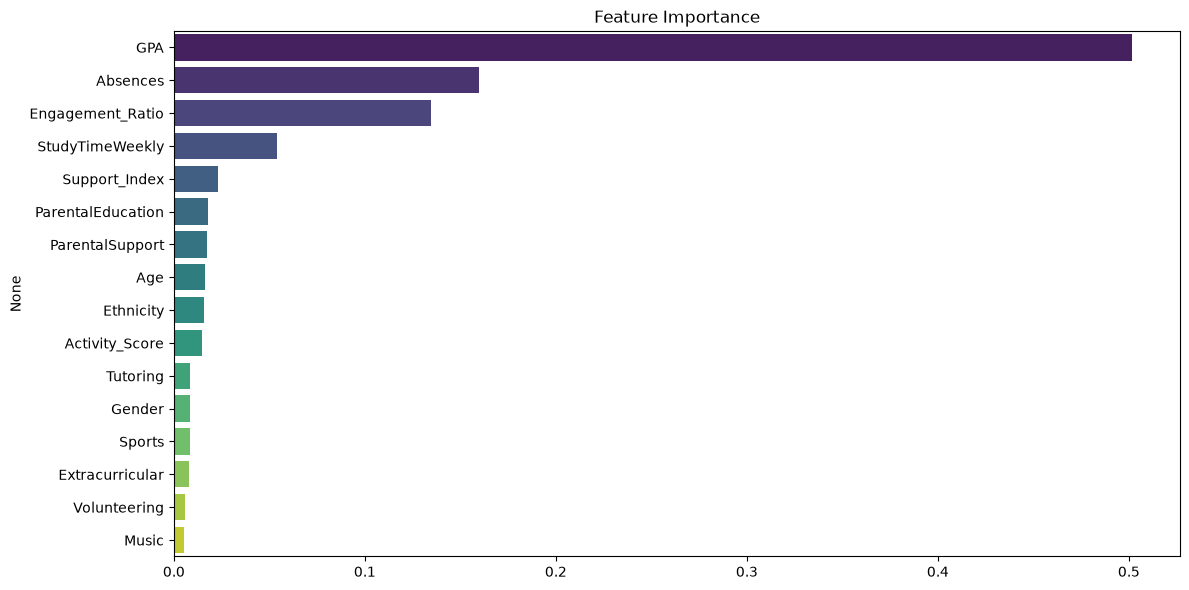

✅ Feature importance saved
GPA                  0.501692
Absences             0.159828
Engagement_Ratio     0.134767
StudyTimeWeekly      0.054158
Support_Index        0.023158
ParentalEducation    0.017802
ParentalSupport      0.017301
Age                  0.016463
Ethnicity            0.015646
Activity_Score       0.014681
Tutoring             0.008462
Gender               0.008421
Sports               0.008378
Extracurricular      0.007936
Volunteering         0.005781
Music                0.005526
dtype: float64


In [8]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('../Documentation/feature_importance.png')
plt.show()
print("✅ Feature importance saved")
print(importances)

In [9]:
top_features = importances.head(10).index.tolist()
top_features.append('GradeClass')

df_final = df[top_features]
print("Selected features:", top_features)
print("Final shape:", df_final.shape)

Selected features: ['GPA', 'Absences', 'Engagement_Ratio', 'StudyTimeWeekly', 'Support_Index', 'ParentalEducation', 'ParentalSupport', 'Age', 'Ethnicity', 'Activity_Score', 'GradeClass']
Final shape: (2392, 11)


In [10]:
df_final.to_csv('../Dataset/final_data.csv', index=False)
print("✅ Final dataset saved")

✅ Final dataset saved
